# 07 Boilerplate Claim Clustering

**Project:** Insurance Fraud Detection Assistant

**Notebook:** `07-boilerplate-claim-clustering.ipynb`

In [47]:
# !pip install sentence-transformers
# !pip install umap-learn
# !pip install hdbscan
# !pip install scikit-learn
# !pip install matplotlib
# !pip install seaborn

In [48]:
# ==========================================
# Notebook 07
# Boilerplate Claim Clustering
# ==========================================

import pandas as pd
import numpy as np

from sentence_transformers import SentenceTransformer

from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN

import umap
import hdbscan

import matplotlib.pyplot as plt
import seaborn as sns

In [49]:
claims_df = pd.read_csv("../data/insurance_claims.csv")

In [50]:
claims_df.head()

,claim_id,claimant_name,vehicle_vin,mechanic_shop,clinic_name,lawyer,claimant_statement,police_report,adjuster_notes,medical_bill,fraud_label
0,CLM001,Wendy Holland,FqH15433919443,Rapid Auto Repair,Care First Clinic,Smith & Associates,A vehicle rear-ended me while I was waiting at...,Witnesses confirmed another driver caused the ...,Section international though many movement.,5072,0
1,CLM002,Douglas Lara,acF49501195178,Rapid Auto Repair,Wellness Recovery Center,Anderson Legal,The vehicle changed lanes unexpectedly and hit...,Police observed damage consistent with reporte...,Budget Mrs part spend middle threat smile incr...,1541,0
2,CLM003,Chloe Murphy,xeQ24677572737,Rapid Auto Repair,Care First Clinic,Justice Partners,I was stopped at a red light when another vehi...,Accident report indicates claimant followed tr...,Similar never box line.,20226,1
3,CLM004,Jodi Reynolds MD,sPL40843321198,Rapid Auto Repair,Wellness Recovery Center,Justice Partners,The vehicle changed lanes unexpectedly and hit...,Police observed damage consistent with reporte...,Section season nor political bank.,7723,0
4,CLM005,Elizabeth Patel,mmr35740163797,Prime Vehicle Repair,Wellness Recovery Center,Smith & Associates,I was driving through an intersection when ano...,Witnesses confirmed another driver caused the ...,Kind compare across audience society.,23376,0


In [51]:
embedding_model = SentenceTransformer("sentence-transformers/all-mpnet-base-v2")

In [52]:
claim_embeddings = embedding_model.encode(
    claims_df["claimant_statement"].tolist(), show_progress_bar=True
)

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

In [53]:
claim_embeddings.shape

(15, 768)

In [54]:
umap_model = umap.UMAP(n_neighbors=5, min_dist=0.2, random_state=42)

In [55]:
embedding_2d = umap_model.fit_transform(claim_embeddings)

d:\Books\projects-nlp-transformers-learning\.projectnlps\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [56]:
embedding_2d.shape

(15, 2)

In [57]:
cluster_df = pd.DataFrame(
    {
        "claim_id": claims_df["claim_id"],
        "x": embedding_2d[:, 0],
        "y": embedding_2d[:, 1],
        "fraud_label": claims_df["fraud_label"],
    }
)

In [58]:
cluster_df.head()

,claim_id,x,y,fraud_label
0,CLM001,3.976617,1.975543,0
1,CLM002,7.194583,5.519600,0
2,CLM003,3.475442,1.992306,1
3,CLM004,7.963412,5.274192,0
4,CLM005,6.819545,3.863978,0


In [59]:
cluster_df.head()

,claim_id,x,y,fraud_label
0,CLM001,3.976617,1.975543,0
1,CLM002,7.194583,5.519600,0
2,CLM003,3.475442,1.992306,1
3,CLM004,7.963412,5.274192,0
4,CLM005,6.819545,3.863978,0


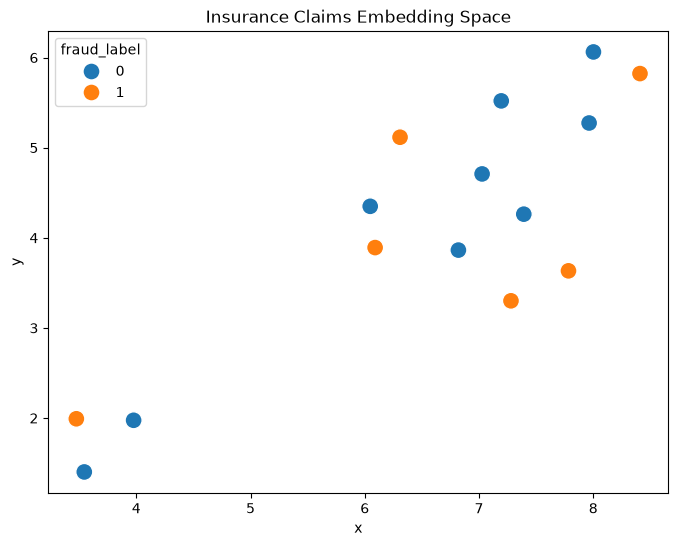

In [60]:
plt.figure(figsize=(8, 6))

sns.scatterplot(data=cluster_df, x="x", y="y", hue="fraud_label", s=150)

plt.title("Insurance Claims Embedding Space")

plt.show()

In [61]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

In [62]:
cluster_df["kmeans_cluster"] = kmeans.fit_predict(claim_embeddings)

In [63]:
cluster_df["kmeans_cluster"].unique()

array([0, 1, 2])

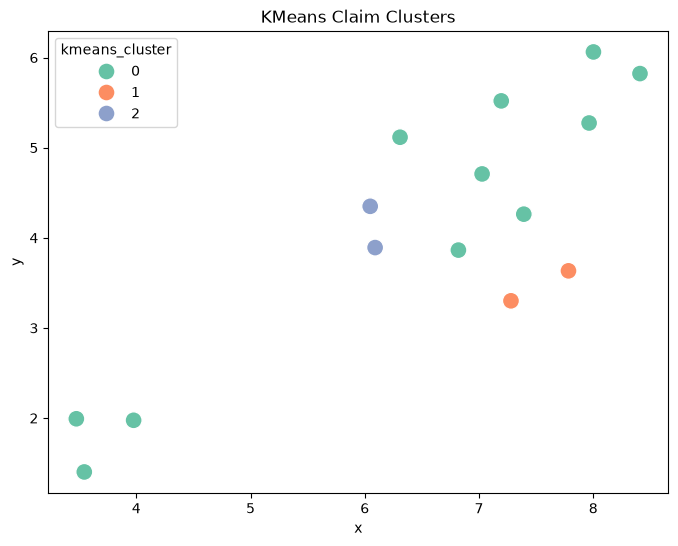

In [64]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=cluster_df, x="x", y="y", hue="kmeans_cluster", palette="Set2", s=150
)

plt.title("KMeans Claim Clusters")

plt.show()

In [65]:
dbscan = DBSCAN(eps=0.35, min_samples=2, metric="cosine")

In [66]:
dbscan_labels = dbscan.fit_predict(claim_embeddings)

In [67]:
cluster_df["dbscan_cluster"] = dbscan_labels

In [68]:
cluster_df["dbscan_cluster"].unique()

array([0, 1], dtype=int64)

In [69]:
cluster_df.head()

,claim_id,x,y,fraud_label,kmeans_cluster,dbscan_cluster
0,CLM001,3.976617,1.975543,0,0,0
1,CLM002,7.194583,5.519600,0,0,0
2,CLM003,3.475442,1.992306,1,0,0
3,CLM004,7.963412,5.274192,0,0,0
4,CLM005,6.819545,3.863978,0,0,0


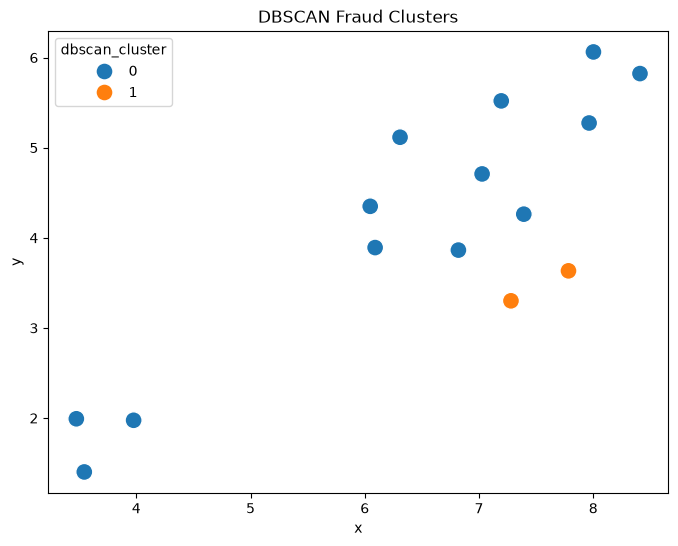

In [70]:
plt.figure(figsize=(8, 6))

sns.scatterplot(data=cluster_df, x="x", y="y", hue="dbscan_cluster", s=150)

plt.title("DBSCAN Fraud Clusters")

plt.show()

In [71]:
hdbscan_model = hdbscan.HDBSCAN(min_cluster_size=2, metric="euclidean")

In [72]:
hdbscan_labels = hdbscan_model.fit_predict(embedding_2d)

In [73]:
cluster_df["hdbscan_cluster"] = hdbscan_labels

In [74]:
cluster_df["hdbscan_cluster"].unique()

array([0, 1], dtype=int64)

In [75]:
cluster_df.head()

,claim_id,x,y,fraud_label,kmeans_cluster,dbscan_cluster,hdbscan_cluster
0,CLM001,3.976617,1.975543,0,0,0,0
1,CLM002,7.194583,5.519600,0,0,0,1
2,CLM003,3.475442,1.992306,1,0,0,0
3,CLM004,7.963412,5.274192,0,0,0,1
4,CLM005,6.819545,3.863978,0,0,0,1


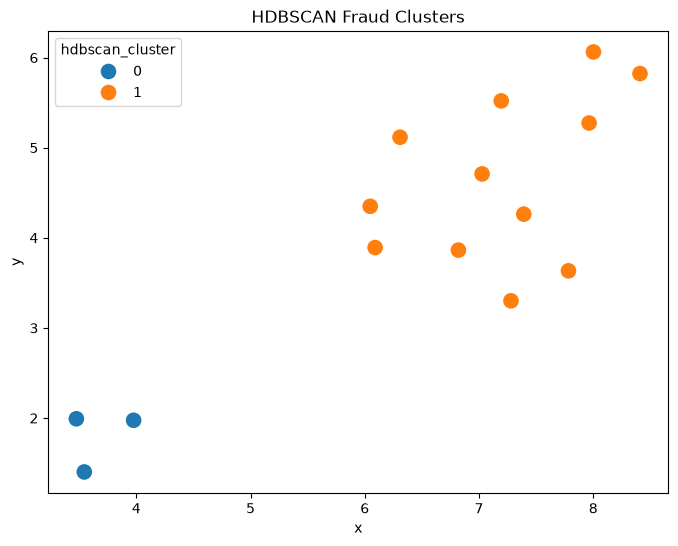

In [76]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=cluster_df, x="x", y="y", hue="hdbscan_cluster", palette="tab10", s=150
)

plt.title("HDBSCAN Fraud Clusters")

plt.show()

In [77]:
cluster_df.groupby("hdbscan_cluster").size()

hdbscan_cluster
0     3
1    12
dtype: int64

In [78]:
cluster_analysis = pd.merge(
    cluster_df, claims_df[["claim_id", "fraud_label"]], on="claim_id"
)

In [79]:
cluster_analysis

,claim_id,x,y,fraud_label_x,kmeans_cluster,dbscan_cluster,hdbscan_cluster,fraud_label_y
0,CLM001,3.976617,1.975543,0,0,0,0,0
1,CLM002,7.194583,5.519600,0,0,0,1,0
2,CLM003,3.475442,1.992306,1,0,0,0,1
3,CLM004,7.963412,5.274192,0,0,0,1,0
4,CLM005,6.819545,3.863978,0,0,0,1,0
5,CLM006,7.782989,3.633888,1,1,1,1,1
6,CLM007,7.391764,4.262562,0,0,0,1,0
7,CLM008,6.090497,3.891883,1,2,0,1,1
8,CLM009,8.408858,5.822570,1,0,0,1,1
9,CLM010,6.308660,5.116253,1,0,0,1,1


In [81]:
cluster_df.groupby("hdbscan_cluster")["fraud_label"].sum()

hdbscan_cluster
0    1
1    5
Name: fraud_label, dtype: int64

In [83]:
cluster_analysis[["claim_id", "hdbscan_cluster", "fraud_label_x"]].sort_values(
    "hdbscan_cluster"
)

,claim_id,hdbscan_cluster,fraud_label_x
0,CLM001,0,0
2,CLM003,0,1
12,CLM013,0,0
1,CLM002,1,0
3,CLM004,1,0
4,CLM005,1,0
5,CLM006,1,1
6,CLM007,1,0
7,CLM008,1,1
8,CLM009,1,1


In [84]:
cluster_analysis[["claim_id", "hdbscan_cluster", "fraud_label_x"]].sort_values(
    "hdbscan_cluster"
)

,claim_id,hdbscan_cluster,fraud_label_x
0,CLM001,0,0
2,CLM003,0,1
12,CLM013,0,0
1,CLM002,1,0
3,CLM004,1,0
4,CLM005,1,0
5,CLM006,1,1
6,CLM007,1,0
7,CLM008,1,1
8,CLM009,1,1


In [86]:
fraud_summary = cluster_analysis.groupby("hdbscan_cluster")["fraud_label_x"].agg(
    ["count", "sum", "mean"]
)

print(fraud_summary)

                 count  sum      mean
hdbscan_cluster                      
0                    3    1  0.333333
1                   12    5  0.416667


In [87]:
suspicious_cluster = 1

In [88]:
members = cluster_analysis[cluster_analysis["hdbscan_cluster"] == suspicious_cluster]

members

,claim_id,x,y,fraud_label_x,kmeans_cluster,dbscan_cluster,hdbscan_cluster,fraud_label_y
1,CLM002,7.194583,5.519600,0,0,0,1,0
3,CLM004,7.963412,5.274192,0,0,0,1,0
4,CLM005,6.819545,3.863978,0,0,0,1,0
5,CLM006,7.782989,3.633888,1,1,1,1,1
6,CLM007,7.391764,4.262562,0,0,0,1,0
7,CLM008,6.090497,3.891883,1,2,0,1,1
8,CLM009,8.408858,5.822570,1,0,0,1,1
9,CLM010,6.308660,5.116253,1,0,0,1,1
10,CLM011,7.279613,3.301143,1,1,1,1,1
11,CLM012,8.001510,6.062582,0,0,0,1,0


In [89]:
for claim_id in members["claim_id"]:

    print("=" * 80)

    claim = claims_df[claims_df["claim_id"] == claim_id].iloc[0]

    print("Claim:", claim_id)

    print()

    print(claim["claimant_statement"])

    print("\n")

Claim: CLM002

The vehicle changed lanes unexpectedly and hit my car.


Claim: CLM004

The vehicle changed lanes unexpectedly and hit my car.


Claim: CLM005

I was driving through an intersection when another vehicle struck my car.


Claim: CLM006



My neck and lower back experienced severe pain immediately after impact.

The collision caused significant emotional distress and loss of mobility.

I continue to experience discomfort.



Claim: CLM007

I was driving through an intersection when another vehicle struck my car.


Claim: CLM008

I was traveling within the speed limit when the accident occurred.


Claim: CLM009

The driver failed to yield and collided with my vehicle.


Claim: CLM010

I was driving through an intersection when another vehicle struck my car.


Claim: CLM011



My neck and lower back experienced severe pain immediately after impact.

The collision caused significant emotional distress and loss of mobility.

I continue to experience discomfort.



Claim: CLM012

In [91]:
fraud_ring_summary = cluster_analysis.groupby("hdbscan_cluster").agg(
    {"claim_id": "count", "fraud_label_x": "sum"}
)

fraud_ring_summary

,claim_id,fraud_label_x
hdbscan_cluster,,
0,3,1
1,12,5


In [92]:
fraud_ring_summary.columns = ["claim_count", "known_fraud_count"]

In [94]:
fraud_ring_summary

,claim_count,known_fraud_count
hdbscan_cluster,,
0,3,1
1,12,5


In [95]:
claims_factory_candidates = fraud_ring_summary[fraud_ring_summary["claim_count"] >= 2]

In [96]:
claims_factory_candidates

,claim_count,known_fraud_count
hdbscan_cluster,,
0,3,1
1,12,5


In [98]:
cluster_df.to_csv("../data/claim_clusters.csv", index=False)

In [99]:
fraud_ring_summary.to_csv("../data/fraud_cluster_summary.csv", index=True)